Install Libraries

In [1]:
!pip install nltk wordcloud pyLDAvis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 47.8 MB/s eta 0:00:00


| Code           | Description                               |
| -------------- | ----------------------------------------- |
| `!pip install` | Installs Python packages in Google Colab. |
| `nltk`         | Used for Natural Language Processing.     |
| `wordcloud`    | Creates Word Cloud visualizations.        |
| `pyLDAvis`     | Interactive visualization for LDA topics. |


Import Libraries

In [2]:
import pandas as pd
import numpy as np

import nltk
import re

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

import matplotlib.pyplot as plt
from wordcloud import WordCloud

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

| Library           | Purpose                              |
| ----------------- | ------------------------------------ |
| pandas            | Read and manipulate datasets         |
| numpy             | Numerical operations                 |
| re                | Regular expression for text cleaning |
| nltk              | Natural Language Toolkit             |
| stopwords         | Remove common English words          |
| WordNetLemmatizer | Convert words to base form           |
| CountVectorizer   | Convert text into numerical features |
| matplotlib        | Visualization                        |
| WordCloud         | Display important words              |


Download NLTK Resources

In [3]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

| Code      | Purpose                                |
| --------- | -------------------------------------- |
| stopwords | Downloads English stop words           |
| wordnet   | Downloads dictionary for lemmatization |
| omw-1.4   | Required for WordNet                   |


Load Dataset

In [4]:
df = pd.read_csv("Coursera_reviews.csv")

| Code            | Description    |
| --------------- | -------------- |
| `pd.read_csv()` | Reads CSV file |
| `df`            | Stores dataset |


Display First Five Rows

In [5]:
df.head()

,reviews,reviewers,date_reviews,rating,course_id
0,"Pretty dry, but I was able to pass with just t...",By Robert S,"Feb 12, 2020",4.0,google-cbrs-cpi-training
1,would be a better experience if the video and ...,By Gabriel E R,"Sep 28, 2020",4.0,google-cbrs-cpi-training
2,Information was perfect! The program itself wa...,By Jacob D,"Apr 08, 2020",4.0,google-cbrs-cpi-training
3,A few grammatical mistakes on test made me do ...,By Dale B,"Feb 24, 2020",4.0,google-cbrs-cpi-training
4,Excellent course and the training provided was...,By Sean G,"Jun 18, 2020",4.0,google-cbrs-cpi-training


Dataset Information

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123469 entries, 0 to 123468
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   reviews       123457 non-null  object 
 1   reviewers     123468 non-null  object 
 2   date_reviews  123468 non-null  object 
 3   rating        123468 non-null  float64
 4   course_id     123468 non-null  object 
dtypes: float64(1), object(4)
memory usage: 4.7+ MB


Number of rows
Number of columns
Column names
Data types
Missing values

Dataset Shape

In [7]:
df.shape

(123469, 5)

Column Names

In [8]:
df.columns

Index(['reviews', 'reviewers', 'date_reviews', 'rating', 'course_id'], dtype='object')

Check Missing Values

In [9]:
df.isnull().sum()

,0
reviews,12
reviewers,1
date_reviews,1
rating,1
course_id,1


Select Only Review Column

In [10]:
df = df[['reviews']]

Rename Column

Renames the column to make it easier to reference.

In [11]:
df.columns = ['Review']

Display Dataset

In [12]:
df.head()

,Review
0,"Pretty dry, but I was able to pass with just t..."
1,would be a better experience if the video and ...
2,Information was perfect! The program itself wa...
3,A few grammatical mistakes on test made me do ...
4,Excellent course and the training provided was...


Check Duplicate Reviews

Counts duplicate reviews.

In [13]:
df.duplicated().sum()

np.int64(83223)

Remove Duplicate Reviews

In [14]:
df.drop_duplicates(inplace=True)

Remove Missing Reviews

Deletes rows containing empty reviews

In [15]:
df.dropna(inplace=True)

Dataset Shape Again

Displays the remaining rows after cleaning.

In [16]:
df.shape

(40245, 1)

Sample Dataset

use a sample to reduce processing time.

In [17]:
df = df.sample(10000, random_state=42)

| Parameter       | Description                                   |
| --------------- | --------------------------------------------- |
| sample(10000)   | Randomly selects 10,000 reviews               |
| random_state=42 | Ensures the same sample is selected every run |


Reset Index

Resets row numbers after sampling.

In [18]:
df.reset_index(drop=True, inplace=True)

Display Dataset

In [19]:
df.head()

,Review
0,During learn this coursera course i had enjo...
1,Excellent course for beginners which includes ...
2,It is good one. A beginner must try this. A li...
3,It is an amazing course. This would help both ...
4,"Thank you for this course, Prof Andrew has a g..."


Create Stop Words

In [20]:
stop_words = set(stopwords.words('english'))

Loads English stop words such as

the
is
are
of
in
on
at

Create Lemmatizer

In [21]:
lemmatizer = WordNetLemmatizer()

| Original | Lemmatized |
| -------- | ---------- |
| studies  | study      |
| running  | running    |
| cars     | car        |
| teachers | teacher    |


Text Cleaning Function

In [22]:
def clean_text(text):

    text = str(text).lower()

    text = re.sub(r'[^a-zA-Z ]', '', text)

    words = text.split()

    words = [word for word in words if word not in stop_words]

    words = [lemmatizer.lemmatize(word) for word in words]

    return " ".join(words)

| Step                         | Purpose                                         |
| ---------------------------- | ----------------------------------------------- |
| Convert to string            | Handles non-text values safely                  |
| Lowercase                    | Makes matching consistent                       |
| Remove numbers & punctuation | Keeps only letters                              |
| Split into words             | Tokenization                                    |
| Remove stop words            | Removes common words                            |
| Lemmatize                    | Converts words to base form                     |
| Join                         | Converts the cleaned words back into a sentence |


Apply Cleaning

Creates a new column containing cleaned reviews.

In [23]:
df["Clean_Review"] = df["Review"].apply(clean_text)

Display Results

In [24]:
df.head()

,Review,Clean_Review
0,During learn this coursera course i had enjo...,learn coursera course enjoyed concept clear in...
1,Excellent course for beginners which includes ...,excellent course beginner includes comprehensi...
2,It is good one. A beginner must try this. A li...,good one beginner must try little exercise giv...
3,It is an amazing course. This would help both ...,amazing course would help computer background ...
4,"Thank you for this course, Prof Andrew has a g...",thank course prof andrew great knowledge could...


Check Cleaned Dataset Shape

In [25]:
df.shape

(10000, 2)

                 Online Course Reviews Dataset
                           (Coursera_reviews.csv)
                                      │
                                      ▼
                            Load Dataset (Pandas)
                                      │
                                      ▼
                          Explore the Dataset (EDA)
                  (head(), info(), shape(), columns)
                                      │
                                      ▼
                     Check Missing & Duplicate Values
                                      │
                                      ▼
                     Remove Missing & Duplicate Reviews
                                      │
                                      ▼
                      Select Only the Review Column
                                      │
                                      ▼
                        Rename Column to "Review"
                                      │
                                      ▼
                   Sample 10,000 Reviews (for faster training)
                                      │
                                      ▼
                            Reset Dataset Index
                                      │
                                      ▼
                      Download NLTK Resources
          (Stopwords, WordNet, Open Multilingual WordNet)
                                      │
                                      ▼
                        Create Stop Words Collection
                                      │
                                      ▼
                          Create WordNet Lemmatizer
                                      │
                                      ▼
                           Text Preprocessing
        ┌─────────────────────────────────────────────────────┐
        │ • Convert to Lowercase                              │
        │ • Remove Numbers                                    │
        │ • Remove Punctuation                                │
        │ • Tokenize Text                                     │
        │ • Remove Stop Words                                 │
        │ • Lemmatize Words                                   │
        └─────────────────────────────────────────────────────┘
                                      │
                                      ▼
                      Create "Clean_Review" Column
                                      │
                                      ▼
                     Cleaned Dataset Ready for LDA

| Input              | Process                           | Output                           |
| ------------------ | --------------------------------- | -------------------------------- |
| Raw Course Reviews | Data Cleaning + NLP Preprocessing | Cleaned Reviews (`Clean_Review`) |


**CountVectorizer, LDA Model, Extraction**

Import LDA

mports the LDA Topic Modeling algorithm.

In [26]:
from sklearn.decomposition import LatentDirichletAllocation

| Code                        | Description                                      |
| --------------------------- | ------------------------------------------------ |
| `from`                      | Imports a specific class from a library.         |
| `sklearn.decomposition`     | Contains decomposition algorithms including LDA. |
| `LatentDirichletAllocation` | LDA algorithm used for Topic Modeling.           |


Create CountVectorizer


Creates the Count Vectorizer used as input for the LDA model.

In [27]:
cv = CountVectorizer(
    max_df=0.95,
    min_df=2,
    stop_words='english'
)

| Parameter              | Description                                                 |
| ---------------------- | ----------------------------------------------------------- |
| `CountVectorizer()`    | Converts text into a numerical matrix based on word counts. |
| `max_df=0.95`          | Removes words appearing in more than 95% of documents.      |
| `min_df=2`             | Keeps words appearing in at least 2 documents.              |
| `stop_words='english'` | Removes common English stop words.                          |


Create Document-Term Matrix

Converts the cleaned reviews into numerical features for LDA.

In [28]:
dtm = cv.fit_transform(df["Clean_Review"])

| Code                 | Description                                                          |
| -------------------- | -------------------------------------------------------------------- |
| `fit_transform()`    | Learns the vocabulary and converts text into a document-term matrix. |
| `df["Clean_Review"]` | Uses the cleaned review text.                                        |
| `dtm`                | Stores the document-term matrix.                                     |


Display Matrix Shape

In [29]:
dtm.shape

(10000, 4425)

10,000 Reviews
4,425 Unique Words

**Create LDA Model**

Creates the LDA Topic Modeling model.

In [30]:
lda_model = LatentDirichletAllocation(
    n_components=5,
    random_state=42
)

| Parameter         | Description                          |
| ----------------- | ------------------------------------ |
| `n_components=5`  | Creates five hidden topics.          |
| `random_state=42` | Produces the same results every run. |

=====


Train the LDA Model

In [31]:
lda_model.fit(dtm)

LatentDirichletAllocation(n_components=5, random_state=42)

| Code    | Description                             |
| ------- | --------------------------------------- |
| `fit()` | Trains the LDA model.                   |
| `dtm`   | Document-Term Matrix used for training. |

=====

Learns hidden topics from the review dataset.

Display Top Words for Each Topic

In [32]:
for index, topic in enumerate(lda_model.components_):

    print(f"\nTopic {index + 1}")

    print([cv.get_feature_names_out()[i]
           for i in topic.argsort()[-10:]])


Topic 1
['thanks', 'professor', 'learned', 'great', 'coursera', 'learn', 'lot', 'really', 'thank', 'course']

Topic 2
['bit', 'like', 'really', 'programming', 'video', 'python', 'good', 'great', 'assignment', 'course']

Topic 3
['neural', 'ng', 'good', 'network', 'great', 'deep', 'andrew', 'learning', 'ai', 'course']

Topic 4
['en', 'finance', 'muy', 'para', 'el', 'la', 'que', 'curso', 'market', 'financial']

Topic 5
['understand', 'really', 'excellent', 'easy', 'beginner', 'great', 'programming', 'python', 'good', 'course']


| Code                      | Description                                   |
| ------------------------- | --------------------------------------------- |
| `enumerate()`             | Iterates through each topic.                  |
| `lda_model.components_`   | Stores word importance for each topic.        |
| `argsort()`               | Sorts words by weight.                        |
| `[-10:]`                  | Selects the top 10 words.                     |
| `get_feature_names_out()` | Converts word indices back into actual words. |


Calculate Topic Probabilities

In [33]:
topic_results = lda_model.transform(dtm)

| Code            | Description                                                    |
| --------------- | -------------------------------------------------------------- |
| `transform()`   | Calculates topic probabilities for each review.                |
| `topic_results` | Stores the probability of each review belonging to each topic. |


Display Shape

In [34]:
topic_results.shape

(10000, 5)

Display Topic Probabilities

In [35]:
topic_results

array([[0.42443584, 0.09425153, 0.01191763, 0.0117753 , 0.45761971],
       [0.02269134, 0.02283342, 0.38621747, 0.02223242, 0.54602534],
       [0.01863646, 0.68386895, 0.01900739, 0.01819717, 0.26029002],
       ...,
       [0.02079325, 0.02042229, 0.02071388, 0.02001328, 0.9180573 ],
       [0.00492667, 0.73123938, 0.25398912, 0.00488379, 0.00496104],
       [0.02543096, 0.3747681 , 0.5491189 , 0.02505306, 0.02562898]])

Assign Topic to Each Review

In [36]:
df["Topic"] = topic_results.argmax(axis=1)

| Code             | Description                                                     |
| ---------------- | --------------------------------------------------------------- |
| `argmax(axis=1)` | Selects the topic with the highest probability for each review. |
| `df["Topic"]`    | Stores the predicted topic number.                              |


Display Dataset

In [37]:
df.head()

,Review,Clean_Review,Topic
0,During learn this coursera course i had enjo...,learn coursera course enjoyed concept clear in...,4
1,Excellent course for beginners which includes ...,excellent course beginner includes comprehensi...,4
2,It is good one. A beginner must try this. A li...,good one beginner must try little exercise giv...,1
3,It is an amazing course. This would help both ...,amazing course would help computer background ...,0
4,"Thank you for this course, Prof Andrew has a g...",thank course prof andrew great knowledge could...,0


Count Reviews in Each Topic

In [38]:
df["Topic"].value_counts()

,count
Topic,
4,3517
0,2821
1,1934
2,1383
3,345


Topic Distribution Bar Chart

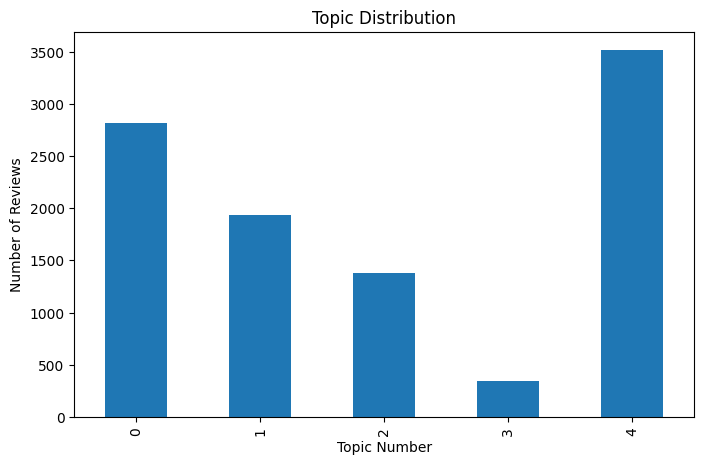

In [39]:
df["Topic"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Topic Distribution")

plt.xlabel("Topic Number")

plt.ylabel("Number of Reviews")

plt.show()

| Function           | Description                       |
| ------------------ | --------------------------------- |
| `value_counts()`   | Counts reviews per topic.         |
| `sort_index()`     | Displays topics in numeric order. |
| `plot(kind="bar")` | Creates a bar chart.              |
| `plt.show()`       | Displays the chart.               |


Clean Reviews
      │
      ▼
CountVectorizer
      │
      ▼
Document-Term Matrix
      │
      ▼
LDA Model
      │
      ▼
Train Model
      │
      ▼
Top 10 Words for Each Topic
      │
      ▼
Topic Probability
      │
      ▼
Assign Topic Number
      │
      ▼
Topic Distribution

| Review                    | Clean_Review          | Topic |
| ------------------------- | --------------------- | ----- |
| Excellent instructor      | excellent instructor  | 0     |
| Assignments are difficult | assignment difficult  | 1     |
| Worth the money           | worth money           | 2     |
| Mobile app is slow        | mobile app slow       | 3     |
| Good customer support     | good customer support | 4     |


**Visualization, Topic Prediction & Save Results**

Import pyLDAvis

In [40]:
import pyLDAvis
import pyLDAvis.lda_model

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


| Code                 | Description                                       |
| -------------------- | ------------------------------------------------- |
| `pyLDAvis`           | Interactive visualization library for LDA         |
| `pyLDAvis.lda_model` | Connects the trained LDA model with visualization |


Interactive Topic Visualization

In [41]:
pyLDAvis.enable_notebook()

panel = pyLDAvis.lda_model.prepare(
    lda_model,
    dtm,
    cv
)

panel

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
0     -0.083610 -0.072351       1        1  28.707082
1     -0.090761 -0.081526       2        1  24.747465
4     -0.127147 -0.039170       3        1  23.287386
2     -0.082910  0.198233       4        1  16.998088
3      0.384428 -0.005185       5        1   6.259980, topic_info=           Term         Freq        Total Category  logprob  loglift
103          ai  1038.000000  1038.000000  Default  30.0000  30.0000
1742       good  1904.000000  1904.000000  Default  29.0000  29.0000
163      andrew   534.000000   534.000000  Default  28.0000  28.0000
850      course  8096.000000  8096.000000  Default  27.0000  27.0000
2290   learning  1357.000000  1357.000000  Default  26.0000  26.0000
...         ...          ...          ...      ...      ...      ...
1574  financial   250.470881   284.603148   Topic5  -3.4206   2.6432
1572    finance   118.475019   187.595894   Topic5  -4.1692   2.3114
3596    shiller    58.324361   165.143900   Topic5  -4.8779   1.7302
3187     python    49.684189  1879.555502   Topic5  -5.0382  -0.8621
348       basic    38.210390   981.735345   Topic5  -5.3008  -0.4752

[348 rows x 6 columns], token_table=      Topic      Freq      Term
term                           
5         1  0.161713  absolute
5         3  0.831666  absolute
103       4  0.999593        ai
106       1  0.988625       aid
114       5  0.975903        al
...     ...       ...       ...
4390      1  0.847521     worth
4390      2  0.149015     worth
4399      2  0.981110   written
4407      1  0.957247      yale
4407      5  0.038290      yale

[649 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[1, 2, 5, 3, 4])

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


| Code                | Description                                   |
| ------------------- | --------------------------------------------- |
| `enable_notebook()` | Enables visualization in Google Colab/Jupyter |
| `prepare()`         | Creates interactive visualization             |
| `panel`             | Displays topic visualization                  |


In [49]:
import warnings

warnings.filterwarnings("ignore")

WordCloud for Each Topic

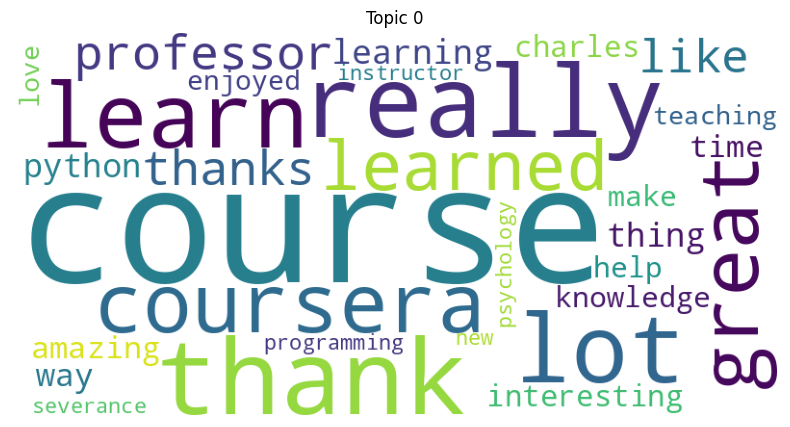

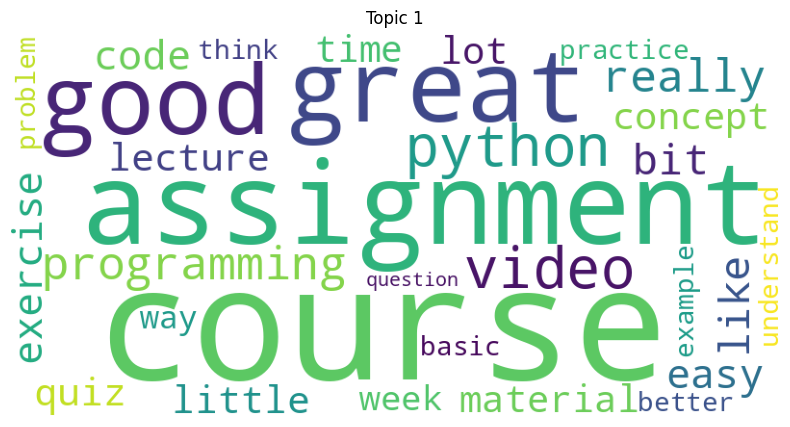

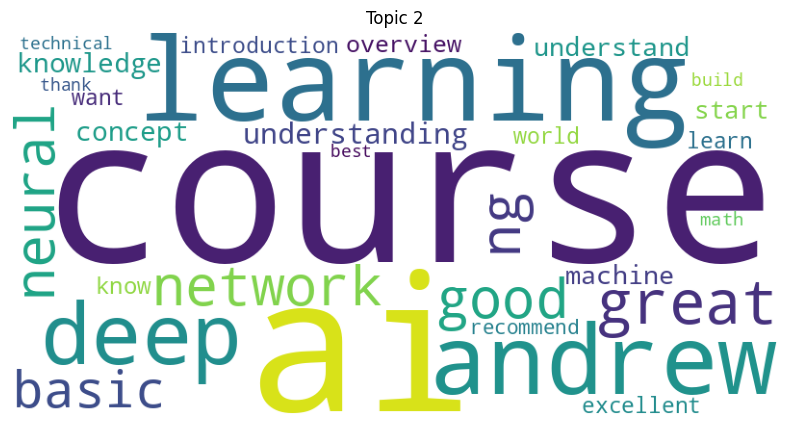

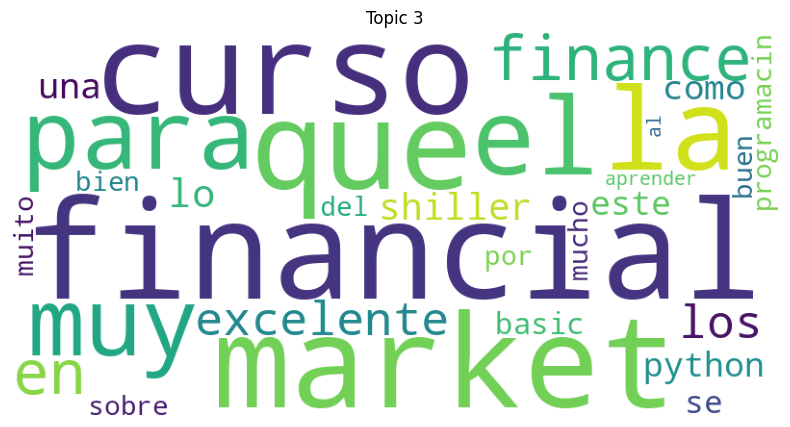

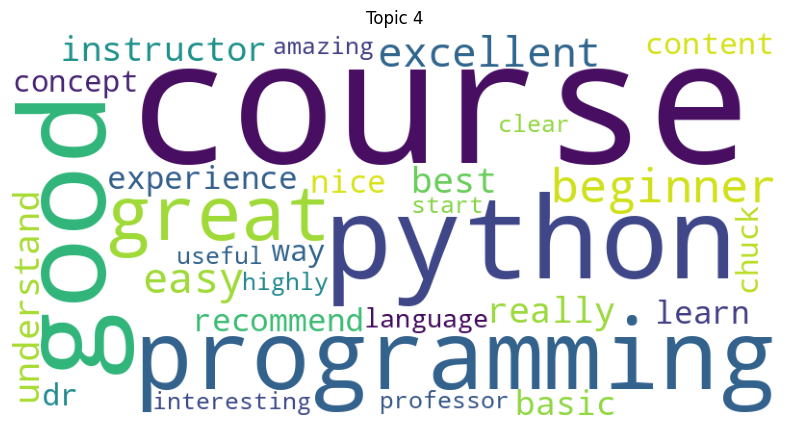

In [50]:
for topic_num, topic in enumerate(lda_model.components_):

    words = {
        cv.get_feature_names_out()[i]: topic[i]
        for i in topic.argsort()[-30:]
    }

    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color="white"
    ).generate_from_frequencies(words)

    plt.figure(figsize=(10,5))

    plt.imshow(wordcloud)

    plt.axis("off")

    plt.title(f"Topic {topic_num}")

    plt.show()

| Function                      | Use                   |
| ----------------------------- | --------------------- |
| `WordCloud()`                 | Creates WordCloud     |
| `generate_from_frequencies()` | Uses LDA word weights |
| `imshow()`                    | Displays WordCloud    |
| `axis("off")`                 | Removes axis          |


Display Reviews with Topic

In [51]:
df[["Review","Topic"]].head(20)

,Review,Topic
0,During learn this coursera course i had enjo...,4
1,Excellent course for beginners which includes ...,4
2,It is good one. A beginner must try this. A li...,1
3,It is an amazing course. This would help both ...,0
4,"Thank you for this course, Prof Andrew has a g...",0
5,It is a little too simple to divide the materi...,1
6,Prof Severance is great! I enjoyed his teachin...,0
7,I was hesitant at first because I thought I wo...,0
8,GOOD FOR THOSE WHO DON'T KNOW PROGRAMMING CONC...,4
9,"Too basic course, good only if you don't have ...",4


Number of Reviews per Topic

In [52]:
topic_counts = df["Topic"].value_counts().sort_index()

print(topic_counts)

Topic
0    2821
1    1934
2    1383
3     345
4    3517
Name: count, dtype: int64


Pie Chart

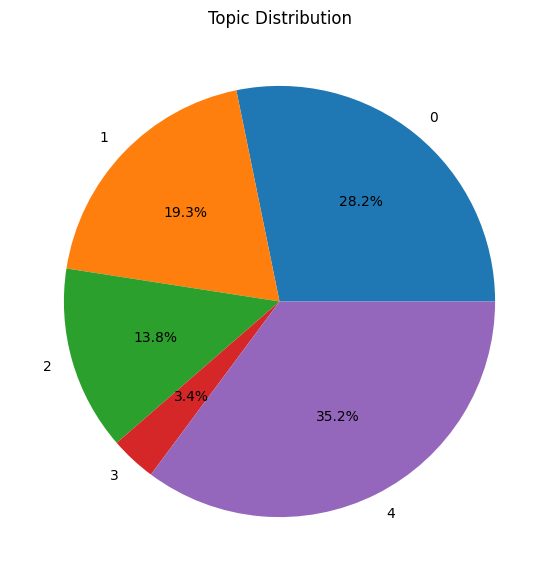

In [48]:
topic_counts.plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(7,7)
)

plt.ylabel("")

plt.title("Topic Distribution")

plt.show()



Save Result

Saves the dataset with predicted topics.

In [53]:
df.to_csv(
    "Course_Review_Topics.csv",
    index=False
)

Download Result

In [54]:
from google.colab import files

files.download("Course_Review_Topics.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Predict Topic for New Review

In [55]:
new_review = [
    "The instructor explained every concept clearly and the assignments were useful."
]

Clean New Review

In [56]:
clean_review = clean_text(new_review[0])

Convert into Count Vector

In [57]:
new_dtm = cv.transform([clean_review])

Predict Topic

In [58]:
prediction = lda_model.transform(new_dtm)

Show Topic Probability

In [59]:
prediction

array([[0.0287194 , 0.23390538, 0.02893805, 0.02858858, 0.67984859]])

Final Predicted Topic

In [60]:
prediction.argmax()

np.int64(4)

Display Topic Name

In [61]:
topic_names = {
    0: "Course Content",
    1: "Instructor Quality",
    2: "Assignments",
    3: "Pricing",
    4: "Platform Experience"
}

print("Predicted Topic :", topic_names[prediction.argmax()])

Predicted Topic : Platform Experience


Test Multiple Reviews

In [62]:
test_reviews = [

    "The instructor explained concepts very clearly.",

    "Assignments are difficult but useful.",

    "Course subscription is expensive.",

    "The mobile app is very slow.",

    "Excellent course content with practical examples."

]

Predict Topics

In [63]:
for review in test_reviews:

    cleaned = clean_text(review)

    vector = cv.transform([cleaned])

    topic = lda_model.transform(vector).argmax()

    print("Review :", review)

    print("Predicted Topic :", topic_names[topic])

    print("-"*50)

Review : The instructor explained concepts very clearly.
Predicted Topic : Platform Experience
--------------------------------------------------
Review : Assignments are difficult but useful.
Predicted Topic : Instructor Quality
--------------------------------------------------
Review : Course subscription is expensive.
Predicted Topic : Course Content
--------------------------------------------------
Review : The mobile app is very slow.
Predicted Topic : Instructor Quality
--------------------------------------------------
Review : Excellent course content with practical examples.
Predicted Topic : Platform Experience
--------------------------------------------------


Coursera Reviews
        │
        ▼
Load Dataset
        │
        ▼
EDA
        │
        ▼
Text Cleaning
        │
        ▼
CountVectorizer
        │
        ▼
Document-Term Matrix
        │
        ▼
LDA Model (5 Topics)
        │
        ▼
Train Model
        │
        ▼
Top Words
        │
        ▼
Assign Topic
        │
        ▼
Topic Distribution
        │
        ▼
WordCloud
        │
        ▼
pyLDAvis
        │
        ▼
Predict New Reviews
        │
        ▼
Save CSV